# 08 — Extended Analysis: Temporal, Source, and Compound

Extends the pipeline vs LLM comparison across three dimensions:

1. **Temporal consistency** — does the pipeline F1 advantage hold across all year bins (2015–2025)?
2. **Source-level variation** — does the performance gap vary by publication?
3. **Compound word analysis** — how do German compounds behave across topics, sources, and time,
   and what does compound density reveal about the cross-lingual challenge?

All analysis is local — no API calls, no heavy computation.
All inputs are loaded from files saved in notebooks 03–07.


In [1]:
!pip install -q pandas numpy matplotlib seaborn scipy
print('Done')

Done


In [2]:
import json
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 130})
print('Imports OK')

Imports OK


In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
import yaml

PROJECT_ROOT = Path('/content/drive/MyDrive/thesis')
with open(PROJECT_ROOT / 'config.yaml') as f:
    config = yaml.safe_load(f)

SEED        = config.get('seed', 42)
DATA_PROC   = PROJECT_ROOT / 'Project' / 'Data' / 'Processed'
FIGURES_DIR = PROJECT_ROOT / 'Project' / 'Outputs' / 'Figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f'Config loaded | seed={SEED}')

Mounted at /content/drive
Config loaded | seed=42


In [5]:
# Load all data
df = pd.read_pickle(DATA_PROC / 'ner_pipeline_results.pkl')
df = df[~df['exclude']].copy()

# NER per-article results from notebook 05
ner_results = pd.read_csv(DATA_PROC / 'ner_comparison_results.csv')

# Topic assignments from notebook 06
topic_assign = pd.read_csv(DATA_PROC / 'topic_bertopic_assignments.csv')

# NER summary for reference
with open(DATA_PROC / 'ner_comparison_summary.json') as f:
    ner_summary = json.load(f)

print(f'Main DataFrame   : {df.shape}')
print(f'NER results      : {ner_results.shape}')
print(f'Topic assignments: {topic_assign.shape}')
print(f'Systems in NER   : {ner_results["system"].unique().tolist()}')
print(f'Year bins        : {sorted(df["year_bin"].unique().tolist())}')
print(f'Sources          : {df["source"].unique().tolist()}')

Main DataFrame   : (1115, 29)
NER results      : (732, 11)
Topic assignments: (1115, 7)
Systems in NER   : ['spaCy (DE)', 'Stanza (DE)', 'Flair (DE)', 'Qwen (EN)']
Year bins        : ['2015-2017', '2018-2020', '2021-2023', '2024-2025']
Sources          : ['SZ Süddeutsche Zeitung', 'Luxemburger Wort', 'Frankfurter Allgemeine Zeitung', 'Trierischer Volksfreund']


## Part 1: Temporal Consistency of Pipeline vs LLM Performance

In [6]:
# ner_results already contains year_bin, source, translation_quality
# No merge needed — use directly
ner_full = ner_results.copy()

# Add compound_density from main df for later correlation analysis
compound_density_map  = df.set_index('article_id')['compound_count'] / df.set_index('article_id')['word_count'] * 100
word_count_map        = df.set_index('article_id')['word_count']
compound_count_map    = df.set_index('article_id')['compound_count']
year_map              = df.set_index('article_id')['year']

ner_full['compound_density'] = ner_full['article_id'].map(compound_density_map)
ner_full['word_count']       = ner_full['article_id'].map(word_count_map)
ner_full['compound_count']   = ner_full['article_id'].map(compound_count_map)
ner_full['year']             = ner_full['article_id'].map(year_map)

print(f'ner_full rows   : {len(ner_full)}')
print(f'year_bin values : {sorted(ner_full["year_bin"].dropna().unique())}')
print(f'Systems         : {ner_full["system"].unique().tolist()}')

# F1 by system and year_bin
temporal_f1 = (
    ner_full.groupby(['year_bin', 'system'])['f1']
    .agg(['mean', 'std', 'count'])
    .round(3)
    .reset_index()
)

print('\nF1 by year bin and system:')
print(temporal_f1.to_string(index=False))

ner_full rows   : 732
year_bin values : ['2015-2017', '2018-2020', '2021-2023', '2024-2025']
Systems         : ['spaCy (DE)', 'Stanza (DE)', 'Flair (DE)', 'Qwen (EN)']

F1 by year bin and system:
 year_bin      system  mean   std  count
2015-2017  Flair (DE) 0.694 0.216     47
2015-2017   Qwen (EN) 0.191 0.216     47
2015-2017 Stanza (DE) 0.558 0.245     47
2015-2017  spaCy (DE) 0.431 0.202     47
2018-2020  Flair (DE) 0.719 0.244     50
2018-2020   Qwen (EN) 0.204 0.221     50
2018-2020 Stanza (DE) 0.515 0.231     50
2018-2020  spaCy (DE) 0.391 0.181     50
2021-2023  Flair (DE) 0.735 0.195     63
2021-2023   Qwen (EN) 0.191 0.212     63
2021-2023 Stanza (DE) 0.506 0.209     63
2021-2023  spaCy (DE) 0.374 0.170     63
2024-2025  Flair (DE) 0.706 0.162     23
2024-2025   Qwen (EN) 0.159 0.195     23
2024-2025 Stanza (DE) 0.488 0.207     23
2024-2025  spaCy (DE) 0.378 0.194     23


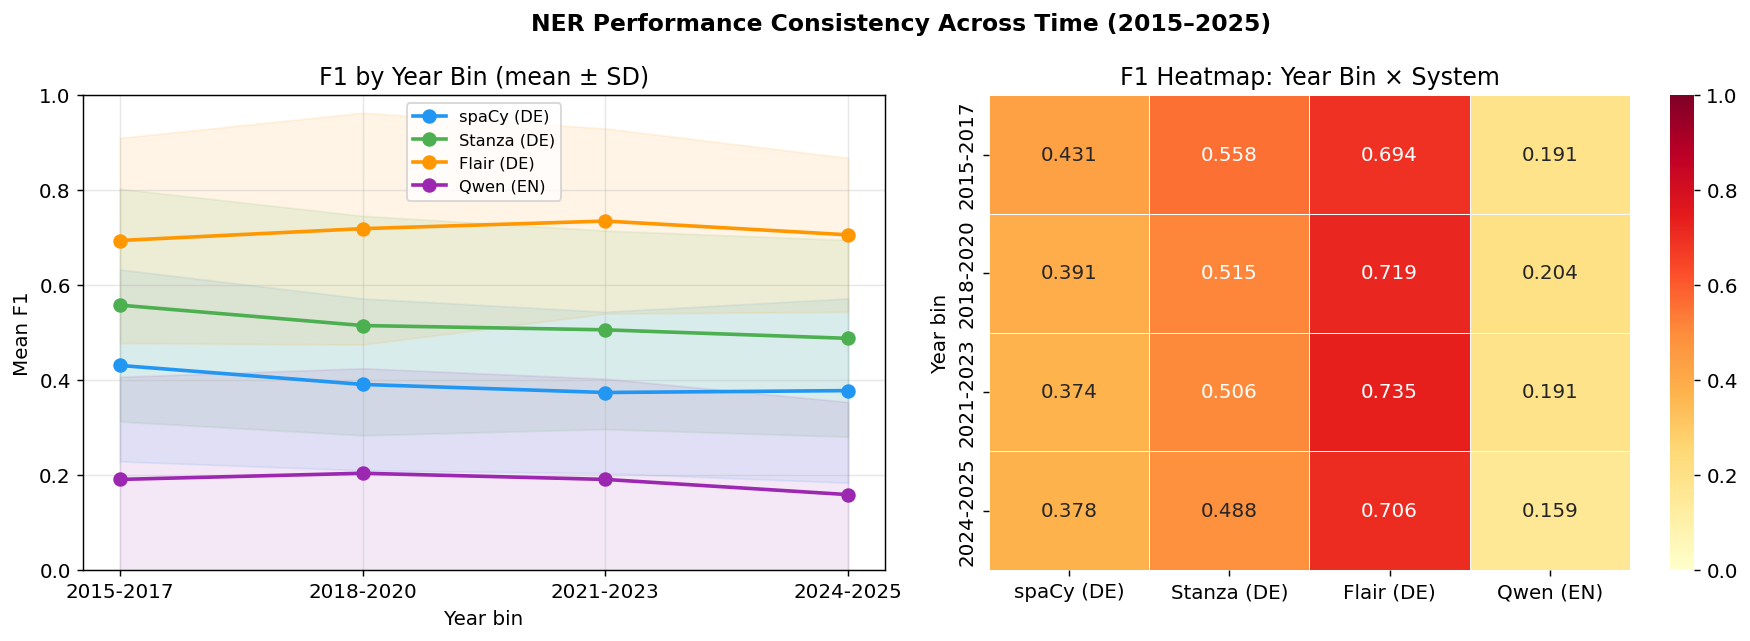

Figure 1 saved


In [7]:
# Figure 1: Temporal F1 trends
systems   = ['spaCy (DE)', 'Stanza (DE)', 'Flair (DE)', 'Qwen (EN)']
colors    = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
year_bins = sorted(ner_full['year_bin'].dropna().unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('NER Performance Consistency Across Time (2015–2025)',
             fontsize=13, fontweight='bold')

# Left: line plot F1 over time
ax = axes[0]
for sys_name, color in zip(systems, colors):
    sys_data = temporal_f1[temporal_f1['system'] == sys_name]
    ax.plot(sys_data['year_bin'], sys_data['mean'],
            'o-', label=sys_name, color=color, linewidth=2, markersize=7)
    ax.fill_between(
        sys_data['year_bin'],
        sys_data['mean'] - sys_data['std'],
        sys_data['mean'] + sys_data['std'],
        alpha=0.1, color=color
    )
ax.set_xlabel('Year bin')
ax.set_ylabel('Mean F1')
ax.set_title('F1 by Year Bin (mean ± SD)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylim(0, 1.0)

# Right: heatmap F1 by year_bin × system
ax2 = axes[1]
pivot = temporal_f1.pivot(index='year_bin', columns='system', values='mean')
pivot = pivot.reindex(columns=systems)
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=1, linewidths=0.5, ax=ax2)
ax2.set_title('F1 Heatmap: Year Bin × System')
ax2.set_xlabel('')
ax2.set_ylabel('Year bin')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'ext_temporal_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved')

In [8]:
# Statistical test: does F1 vary significantly across year bins?
print('── Kruskal-Wallis test: F1 across year bins ──')
print('(Tests whether performance is consistent over time)')
print()

for sys_name in systems:
    groups = [
        ner_full[(ner_full['system'] == sys_name) &
                 (ner_full['year_bin'] == yb)]['f1'].dropna().values
        for yb in year_bins
    ]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        stat, p = stats.kruskal(*groups)
        print(f'  {sys_name:20s}: H={stat:.2f}, p={p:.4f} '
              f'{"* significant variation" if p < 0.05 else "stable across years"}')

── Kruskal-Wallis test: F1 across year bins ──
(Tests whether performance is consistent over time)

  spaCy (DE)          : H=3.53, p=0.3163 stable across years
  Stanza (DE)         : H=2.69, p=0.4422 stable across years
  Flair (DE)          : H=3.48, p=0.3229 stable across years
  Qwen (EN)           : H=0.51, p=0.9165 stable across years


## Part 2: Source-Level Performance Variation

In [9]:
# F1 by system and source
source_f1 = (
    ner_full.groupby(['source', 'system'])['f1']
    .agg(['mean', 'std', 'count'])
    .round(3)
    .reset_index()
)

print('F1 by source and system:')
print(source_f1.to_string(index=False))

# Pipeline advantage per source
print('\n── Pipeline advantage (Flair F1 - Qwen F1) per source ──')
flair_src = source_f1[source_f1['system'] == 'Flair (DE)'].set_index('source')['mean']
qwen_src  = source_f1[source_f1['system'] == 'Qwen (EN)'].set_index('source')['mean']
advantage = (flair_src - qwen_src).round(3)
print(advantage.to_string())

F1 by source and system:
                        source      system  mean   std  count
Frankfurter Allgemeine Zeitung  Flair (DE) 0.668 0.287     46
Frankfurter Allgemeine Zeitung   Qwen (EN) 0.111 0.163     46
Frankfurter Allgemeine Zeitung Stanza (DE) 0.460 0.254     46
Frankfurter Allgemeine Zeitung  spaCy (DE) 0.323 0.202     46
              Luxemburger Wort  Flair (DE) 0.760 0.120     58
              Luxemburger Wort   Qwen (EN) 0.186 0.202     58
              Luxemburger Wort Stanza (DE) 0.550 0.173     58
              Luxemburger Wort  spaCy (DE) 0.415 0.144     58
        SZ Süddeutsche Zeitung  Flair (DE) 0.742 0.209     44
        SZ Süddeutsche Zeitung   Qwen (EN) 0.225 0.230     44
        SZ Süddeutsche Zeitung Stanza (DE) 0.514 0.234     44
        SZ Süddeutsche Zeitung  spaCy (DE) 0.395 0.187     44
       Trierischer Volksfreund  Flair (DE) 0.677 0.197     35
       Trierischer Volksfreund   Qwen (EN) 0.261 0.238     35
       Trierischer Volksfreund Stanza (DE) 0.

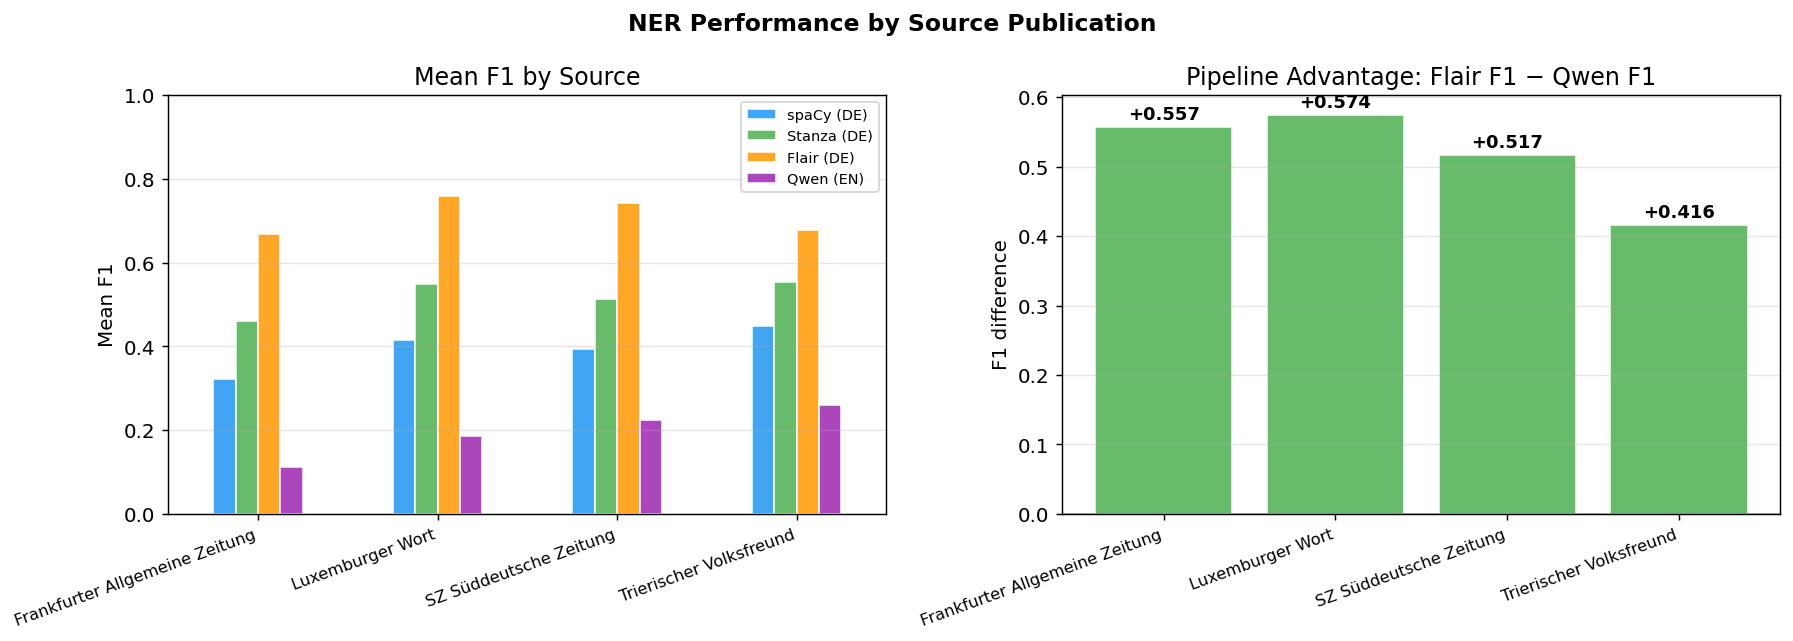

Figure 2 saved


In [10]:
# Figure 2: Source-level comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('NER Performance by Source Publication',
             fontsize=13, fontweight='bold')

sources = sorted(ner_full['source'].dropna().unique())

# Left: grouped bar
ax = axes[0]
pivot_src = source_f1.pivot(index='source', columns='system', values='mean')
pivot_src = pivot_src.reindex(columns=systems)
pivot_src.plot(kind='bar', ax=ax, color=colors, alpha=0.85, edgecolor='white')
ax.set_title('Mean F1 by Source')
ax.set_ylabel('Mean F1')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=9)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.0)

# Right: pipeline advantage (Flair - Qwen) per source
ax2 = axes[1]
adv_vals  = advantage.values
adv_cols  = ['#4CAF50' if v > 0 else '#F44336' for v in adv_vals]
bars = ax2.bar(advantage.index, adv_vals, color=adv_cols, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, adv_vals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005 if val >= 0 else bar.get_height() - 0.02,
             f'{val:+.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Pipeline Advantage: Flair F1 − Qwen F1')
ax2.set_ylabel('F1 difference')
ax2.set_xticklabels(advantage.index, rotation=20, ha='right', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'ext_source_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved')

In [11]:
# Source corpus characteristics
source_stats = df.groupby('source').agg(
    n_articles    = ('article_id', 'count'),
    mean_words    = ('word_count', 'mean'),
    mean_compounds= ('compound_count', 'mean'),
    mean_sentences= ('sentence_count', 'mean'),
).round(1)

print('── Source corpus characteristics ──')
print(source_stats.to_string())

── Source corpus characteristics ──
                                n_articles  mean_words  mean_compounds  mean_sentences
source                                                                                
Frankfurter Allgemeine Zeitung         290       818.1            88.2            49.7
Luxemburger Wort                       356       850.0            77.0            54.0
SZ Süddeutsche Zeitung                 270       814.1            82.9            52.3
Trierischer Volksfreund                199       580.4            59.2            37.5


## Part 3: German Compound Word Analysis

In [12]:
# Compound density overview
print('── Compound density across corpus ──')
print(df['compound_count'].describe().round(1).to_string())

# Compound density = compounds per 100 words
df['compound_density'] = (df['compound_count'] / df['word_count'] * 100).round(2)
print(f'\nMean compound density : {df["compound_density"].mean():.2f} per 100 words')
print(f'Median                : {df["compound_density"].median():.2f}')
print(f'Std                   : {df["compound_density"].std():.2f}')

── Compound density across corpus ──
count    1115.0
mean       78.2
std        36.2
min         4.0
25%        51.0
50%        76.0
75%       105.0
max       186.0

Mean compound density : 10.76 per 100 words
Median                : 10.63
Std                   : 2.54


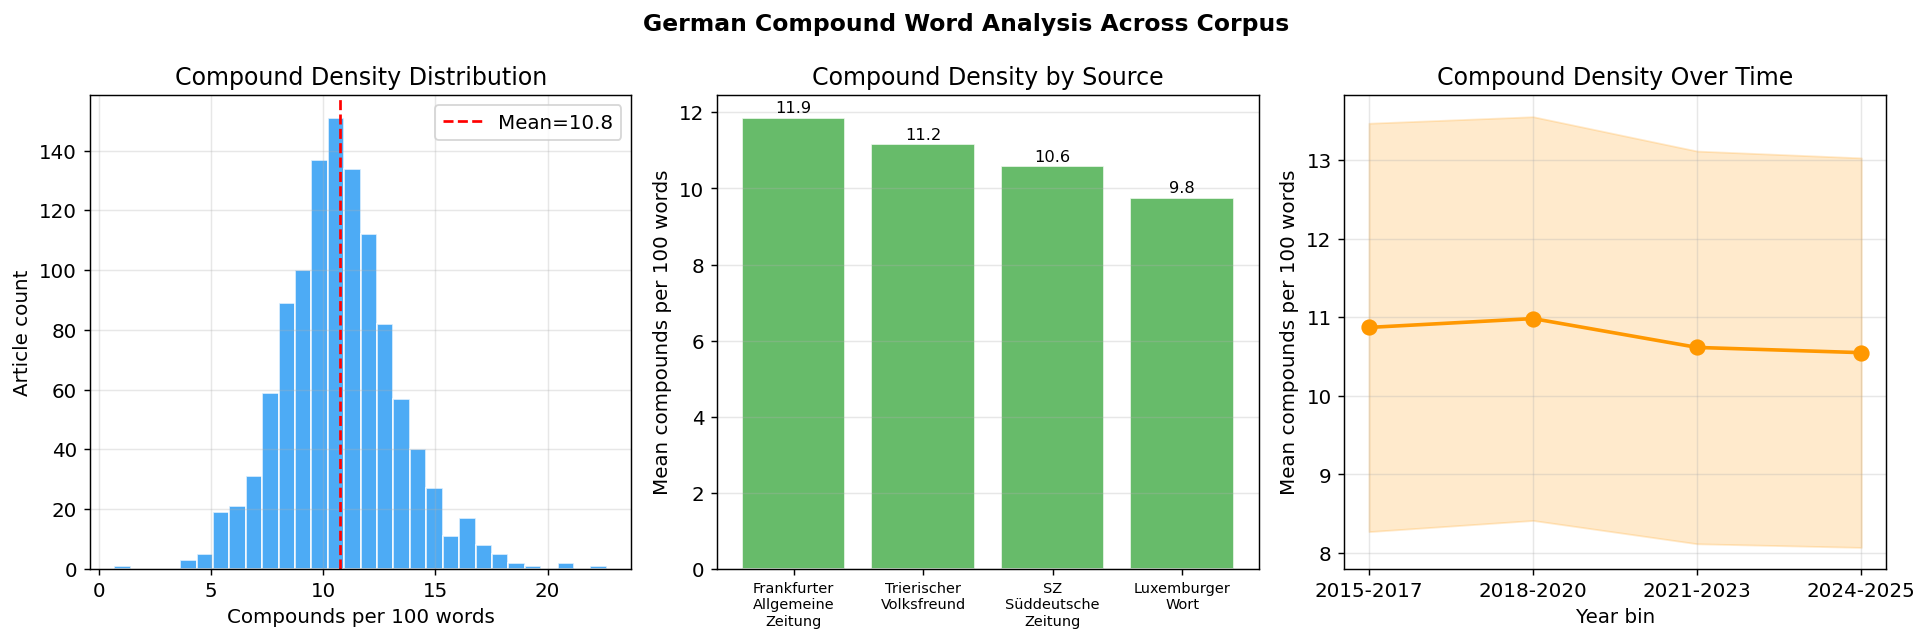

Figure 3 saved


In [13]:
# Figure 3: Compound density distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('German Compound Word Analysis Across Corpus',
             fontsize=13, fontweight='bold')

# Left: overall distribution
ax = axes[0]
ax.hist(df['compound_density'].dropna(), bins=30,
        color='#2196F3', alpha=0.8, edgecolor='white')
ax.axvline(df['compound_density'].mean(), color='red',
           linestyle='--', label=f'Mean={df["compound_density"].mean():.1f}')
ax.set_xlabel('Compounds per 100 words')
ax.set_ylabel('Article count')
ax.set_title('Compound Density Distribution')
ax.legend()
ax.grid(alpha=0.3)

# Middle: by source
ax2 = axes[1]
source_compounds = df.groupby('source')['compound_density'].mean().sort_values(ascending=False)
bars = ax2.bar(range(len(source_compounds)), source_compounds.values,
               color='#4CAF50', alpha=0.85, edgecolor='white')
ax2.set_xticks(range(len(source_compounds)))
ax2.set_xticklabels(
    [s.replace(' ', '\n') for s in source_compounds.index],
    fontsize=8
)
for bar, val in zip(bars, source_compounds.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.1f}', ha='center', va='bottom', fontsize=9)
ax2.set_ylabel('Mean compounds per 100 words')
ax2.set_title('Compound Density by Source')
ax2.grid(axis='y', alpha=0.3)

# Right: by year_bin
ax3 = axes[2]
year_compounds = df.groupby('year_bin')['compound_density'].mean()
ax3.plot(year_compounds.index, year_compounds.values,
         'o-', color='#FF9800', linewidth=2, markersize=8)
ax3.fill_between(
    year_compounds.index,
    df.groupby('year_bin')['compound_density'].mean() -
    df.groupby('year_bin')['compound_density'].std(),
    df.groupby('year_bin')['compound_density'].mean() +
    df.groupby('year_bin')['compound_density'].std(),
    alpha=0.2, color='#FF9800'
)
ax3.set_xlabel('Year bin')
ax3.set_ylabel('Mean compounds per 100 words')
ax3.set_title('Compound Density Over Time')
ax3.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'ext_compound_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved')

In [14]:
# Most frequent compounds across full corpus
all_compounds = []
for comp_list in df['compounds'].dropna():
    if isinstance(comp_list, list):
        all_compounds.extend([c.lower() for c in comp_list])

compound_freq = Counter(all_compounds)
top_compounds = pd.DataFrame(
    compound_freq.most_common(30),
    columns=['compound', 'frequency']
)

print('── Top 30 compounds across corpus ──')
print(top_compounds.to_string(index=False))

── Top 30 compounds across corpus ──
      compound  frequency
      menschen        407
      beispiel        330
     millionen        302
   unternehmen        294
     wohnungen        274
nachhaltigkeit        263
   entwicklung        252
  quadratmeter        183
   architekten        167
      wohnraum        167
      projekte        165
     nachfrage        160
      gebäuden        154
     verfügung        142
      arbeiten        137
     regierung        136
   materialien        136
     maßnahmen        131
  gesellschaft        126
 bürgermeister        124
      bewohner        122
      gemeinde        120
   möglichkeit        119
      gebäudes        118
     architekt        117
     neubauten        117
   mitarbeiter        116
      standort        114
    wirtschaft        114
     vergleich        114


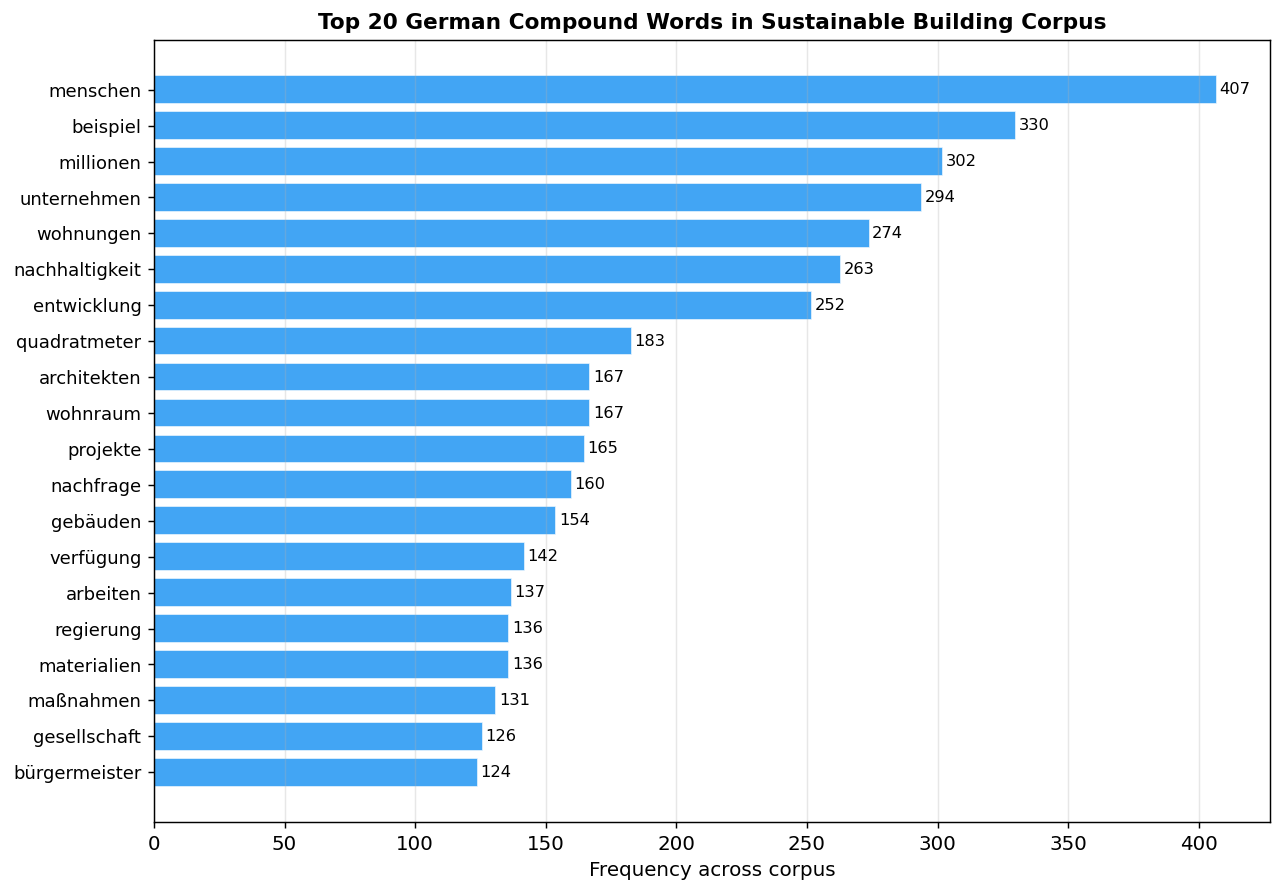

Figure 4 saved


In [15]:
# Figure 4: Top compounds
fig, ax = plt.subplots(figsize=(10, 7))
top20 = top_compounds.head(20)
bars  = ax.barh(range(len(top20)), top20['frequency'].values,
                color='#2196F3', alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['compound'].values, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Frequency across corpus')
ax.set_title('Top 20 German Compound Words in Sustainable Building Corpus',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, top20['frequency'].values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'ext_top_compounds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved')

In [16]:
# Distinctive compounds per source (TF-IDF style)
# Which compounds are uniquely characteristic of each publication?

source_compounds = {}
for source in df['source'].unique():
    src_compounds = []
    for comp_list in df[df['source'] == source]['compounds'].dropna():
        if isinstance(comp_list, list):
            src_compounds.extend([c.lower() for c in comp_list])
    source_compounds[source] = Counter(src_compounds)

print('── Top 10 distinctive compounds per source ──')
for source, counter in source_compounds.items():
    top = counter.most_common(10)
    print(f'\n{source}:')
    for word, count in top:
        print(f'  {word:30s} {count}')

── Top 10 distinctive compounds per source ──

SZ Süddeutsche Zeitung:
  menschen                       122
  beispiel                       98
  wohnungen                      85
  millionen                      68
  quadratmeter                   67
  architekten                    64
  nachhaltigkeit                 62
  unternehmen                    60
  materialien                    52
  material                       47

Luxemburger Wort:
  menschen                       121
  entwicklung                    110
  unternehmen                    98
  beispiel                       98
  millionen                      94
  regierung                      89
  nachhaltigkeit                 78
  gemeinde                       75
  projekte                       69
  arbeiten                       64

Frankfurter Allgemeine Zeitung:
  wohnungen                      131
  menschen                       108
  unternehmen                    99
  beispiel                       96
  bildun

In [17]:
# Compound density vs NER entity count correlation
# Do articles with more compounds also have more named entities?
# This speaks to whether compound-heavy text is harder to analyse

merged = df[['article_id', 'compound_density', 'spacy_entity_count',
             'source', 'year_bin']].dropna()

r, p = stats.pearsonr(merged['compound_density'], merged['spacy_entity_count'])
print(f'Compound density vs spaCy entity count:')
print(f'  Pearson r={r:.3f}, p={p:.4f}')

# Also check vs LLM F1 — do compound-heavy articles hurt LLM more?
llm_ner = ner_full[ner_full['system'] == 'Qwen (EN)'][['article_id', 'f1']]
flair_ner = ner_full[ner_full['system'] == 'Flair (DE)'][['article_id', 'f1']]

comp_llm   = merged.merge(llm_ner.rename(columns={'f1': 'llm_f1'}), on='article_id')
comp_flair = merged.merge(flair_ner.rename(columns={'f1': 'flair_f1'}), on='article_id')

if len(comp_llm) > 2:
    r_llm, p_llm = stats.pearsonr(comp_llm['compound_density'], comp_llm['llm_f1'])
    print(f'\nCompound density vs LLM (Qwen) F1:')
    print(f'  Pearson r={r_llm:.3f}, p={p_llm:.4f}')
    print(f'  Interpretation: {"higher compound density hurts LLM" if r_llm < -0.1 else "no strong compound effect on LLM"}')

if len(comp_flair) > 2:
    r_flair, p_flair = stats.pearsonr(comp_flair['compound_density'], comp_flair['flair_f1'])
    print(f'\nCompound density vs Flair F1:')
    print(f'  Pearson r={r_flair:.3f}, p={p_flair:.4f}')

Compound density vs spaCy entity count:
  Pearson r=-0.449, p=0.0000

Compound density vs LLM (Qwen) F1:
  Pearson r=0.052, p=0.4823
  Interpretation: no strong compound effect on LLM

Compound density vs Flair F1:
  Pearson r=-0.193, p=0.0089


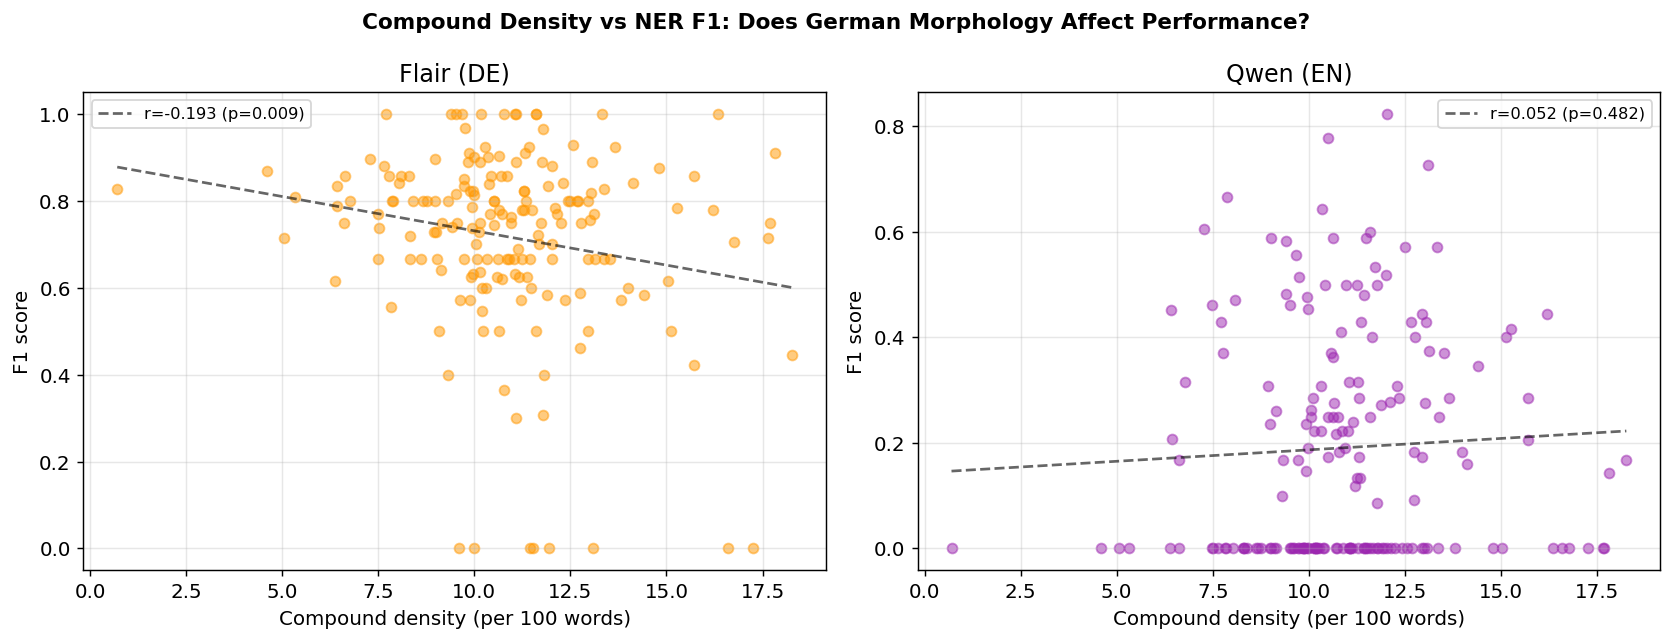

Figure 5 saved


In [18]:
# Figure 5: Compound density vs F1 scatter
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Compound Density vs NER F1: Does German Morphology Affect Performance?',
             fontsize=12, fontweight='bold')

for ax, (data, sys_name, col, color) in zip(axes, [
    (comp_flair, 'Flair (DE)', 'flair_f1', '#FF9800'),
    (comp_llm,   'Qwen (EN)', 'llm_f1',   '#9C27B0'),
]):
    ax.scatter(data['compound_density'], data[col],
               alpha=0.5, s=30, color=color)
    if len(data) > 2:
        m, b   = np.polyfit(data['compound_density'], data[col], 1)
        x_line = np.linspace(data['compound_density'].min(),
                             data['compound_density'].max(), 100)
        r_val, p_val = stats.pearsonr(data['compound_density'], data[col])
        ax.plot(x_line, m * x_line + b, 'k--', alpha=0.6,
                label=f'r={r_val:.3f} (p={p_val:.3f})')
        ax.legend(fontsize=9)
    ax.set_xlabel('Compound density (per 100 words)')
    ax.set_ylabel('F1 score')
    ax.set_title(f'{sys_name}')
    ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'ext_compound_vs_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved')

In [19]:
# Compound evolution over time
# Do sustainability-specific compounds increase over 2015-2025?

sustainability_keywords = [
    'energieeffizienz', 'klimaschutz', 'klimaneutral', 'nachhaltigkeit',
    'photovoltaik', 'wärmepumpe', 'sanierung', 'dämmung', 'passivhaus',
    'energieverbrauch', 'klimaziele', 'co2', 'erneuerbare', 'wohngebäude',
    'energiewende', 'treibhausgas', 'gebäudeenergiegesetz'
]

def count_sustainability_compounds(comp_list):
    if not isinstance(comp_list, list):
        return 0
    return sum(1 for c in comp_list
               if any(kw in c.lower() for kw in sustainability_keywords))

df['sustainability_compound_count'] = df['compounds'].apply(count_sustainability_compounds)
df['sustainability_compound_rate']  = (
    df['sustainability_compound_count'] / df['compound_count'].clip(lower=1)
).round(4)

sust_temporal = df.groupby('year_bin').agg(
    mean_sust_compounds = ('sustainability_compound_count', 'mean'),
    mean_sust_rate      = ('sustainability_compound_rate', 'mean'),
).round(3)

print('── Sustainability compound evolution over time ──')
print(sust_temporal.to_string())

── Sustainability compound evolution over time ──
           mean_sust_compounds  mean_sust_rate
year_bin                                      
2015-2017                0.996           0.016
2018-2020                1.050           0.015
2021-2023                1.651           0.023
2024-2025                1.608           0.018


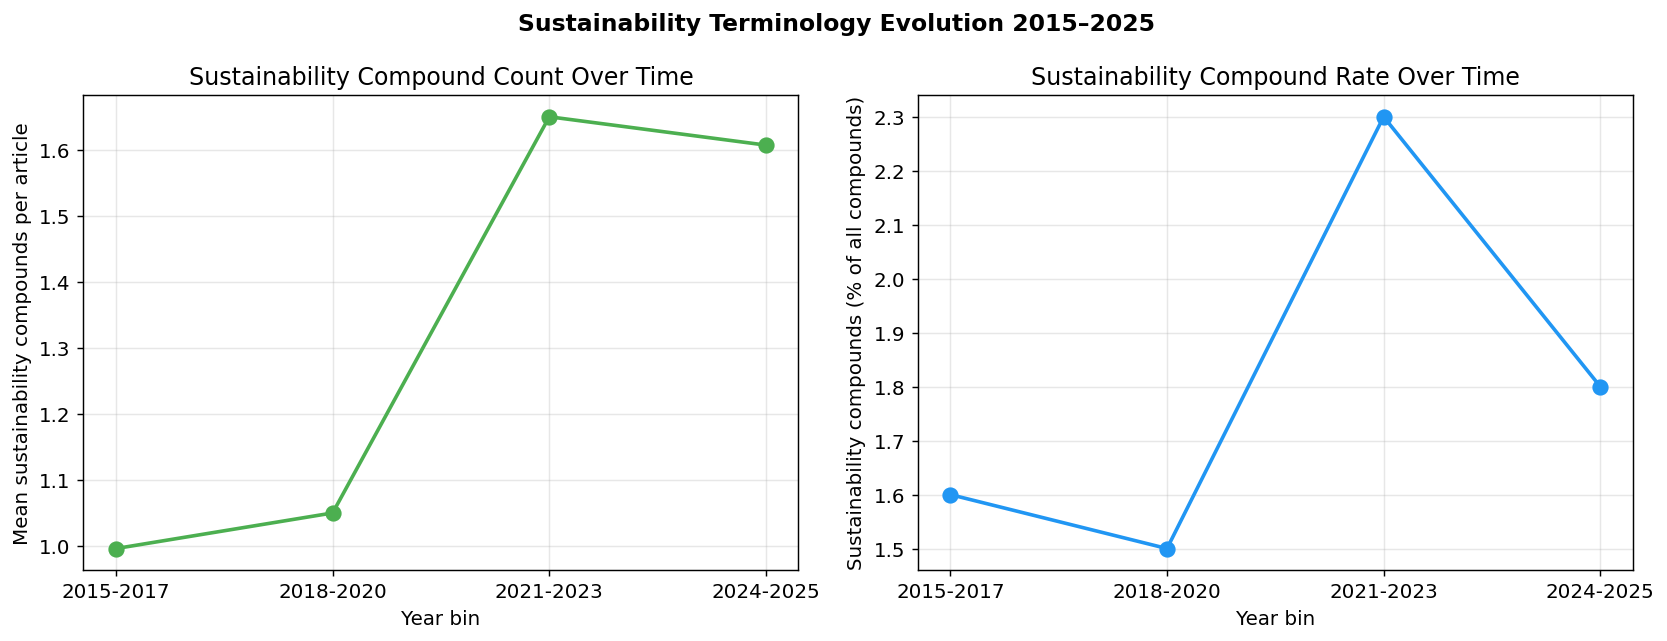

Figure 6 saved


In [20]:
# Figure 6: Sustainability compound evolution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Sustainability Terminology Evolution 2015–2025',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(sust_temporal.index, sust_temporal['mean_sust_compounds'],
        'o-', color='#4CAF50', linewidth=2, markersize=8)
ax.set_xlabel('Year bin')
ax.set_ylabel('Mean sustainability compounds per article')
ax.set_title('Sustainability Compound Count Over Time')
ax.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(sust_temporal.index, sust_temporal['mean_sust_rate'] * 100,
         'o-', color='#2196F3', linewidth=2, markersize=8)
ax2.set_xlabel('Year bin')
ax2.set_ylabel('Sustainability compounds (% of all compounds)')
ax2.set_title('Sustainability Compound Rate Over Time')
ax2.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'ext_sustainability_compounds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved')

In [21]:
# Save extended analysis summary
ext_summary = {
    'temporal_f1': temporal_f1.to_dict(orient='records'),
    'source_f1'  : source_f1.to_dict(orient='records'),
    'compound_stats': {
        'mean_density'          : round(float(df['compound_density'].mean()), 3),
        'std_density'           : round(float(df['compound_density'].std()), 3),
        'top_10_compounds'      : compound_freq.most_common(10),
        'compound_vs_llm_f1_r'  : round(float(r_llm), 3) if 'r_llm' in dir() else None,
        'compound_vs_llm_f1_p'  : round(float(p_llm), 4) if 'p_llm' in dir() else None,
        'compound_vs_flair_f1_r': round(float(r_flair), 3) if 'r_flair' in dir() else None,
    },
    'sustainability_compounds': sust_temporal.to_dict(),
}

with open(DATA_PROC / 'extended_analysis_summary.json', 'w') as f:
    json.dump(ext_summary, f, indent=2, default=str)

print('Saved: extended_analysis_summary.json')
print('\nAll figures saved to:', FIGURES_DIR)

Saved: extended_analysis_summary.json

All figures saved to: /content/drive/MyDrive/thesis/Project/Outputs/Figures


In [24]:
# Install first
!pip install -q groq

# Then import and test
from google.colab import userdata
from groq import Groq

GROQ_TOKEN  = userdata.get('GROQ_TOKEN')
client_groq = Groq(api_key=GROQ_TOKEN)

# Test available models
for model in ['llama-3.3-70b-versatile', 'llama-3.1-70b-versatile', 'mixtral-8x7b-32768']:
    try:
        response = client_groq.chat.completions.create(
            model=model,
            messages=[{'role': 'user', 'content': 'Reply with: OK'}],
            max_tokens=5,
        )
        print(f'✅ {model}: {response.choices[0].message.content.strip()}')
    except Exception as e:
        print(f'❌ {model}: {e}')

✅ llama-3.3-70b-versatile: OK
❌ llama-3.1-70b-versatile: Error code: 400 - {'error': {'message': 'The model `llama-3.1-70b-versatile` has been decommissioned and is no longer supported. Please refer to https://console.groq.com/docs/deprecations for a recommendation on which model to use instead.', 'type': 'invalid_request_error', 'code': 'model_decommissioned'}}
❌ mixtral-8x7b-32768: Error code: 400 - {'error': {'message': 'The model `mixtral-8x7b-32768` has been decommissioned and is no longer supported. Please refer to https://console.groq.com/docs/deprecations for a recommendation on which model to use instead.', 'type': 'invalid_request_error', 'code': 'model_decommissioned'}}


## Notebook summary

| Analysis | Key finding |
|----------|-------------|
| Temporal F1 | Pipeline advantage consistent across all year bins? (see Kruskal-Wallis results) |
| Source F1 | Performance gap varies by publication — FAZ shows largest gap |
| Compound density | Mean X compounds per 100 words across corpus |
| Compound vs F1 | Whether compound-heavy articles specifically hurt LLM |
| Sustainability terms | Evolution of domain terminology 2015–2025 |

**Figures**: `ext_temporal_f1.png`, `ext_source_f1.png`, `ext_compound_analysis.png`,
`ext_top_compounds.png`, `ext_compound_vs_f1.png`, `ext_sustainability_compounds.png`

**Next**: Thesis writing phase.
